In [7]:
import seaborn as sns
import pandas  as pd
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

In [6]:
titanic = sns.load_dataset('titanic')
titanic.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [8]:
#Missing values
print(titanic.isnull().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64


In [9]:
data = titanic[['age', 'fare', 'pclass', 'sex']]
data = pd.get_dummies(data, drop_first=True)
data.head()

,age,fare,pclass,sex_male
0,22.0,7.2500,3,True
1,38.0,71.2833,1,False
2,26.0,7.9250,3,False
3,35.0,53.1000,1,False
4,35.0,8.0500,3,True


In [10]:
imputer = IterativeImputer(max_iter=10, random_state=0)

In [11]:
data_imputed = pd.DataFrame(imputer.fit_transform(data), columns=data.columns)

In [12]:
print("Datos originales:")
print(data.head(30))

print("\nDatos imputados:")
print(data_imputed.head(30))

Datos originales:
     age      fare  pclass  sex_male
0   22.0    7.2500       3      True
1   38.0   71.2833       1     False
2   26.0    7.9250       3     False
3   35.0   53.1000       1     False
4   35.0    8.0500       3      True
5    NaN    8.4583       3      True
6   54.0   51.8625       1      True
7    2.0   21.0750       3      True
8   27.0   11.1333       3     False
9   14.0   30.0708       2     False
10   4.0   16.7000       3     False
11  58.0   26.5500       1     False
12  20.0    8.0500       3      True
13  39.0   31.2750       3      True
14  14.0    7.8542       3     False
15  55.0   16.0000       2     False
16   2.0   29.1250       3      True
17   NaN   13.0000       2      True
18  31.0   18.0000       3     False
19   NaN    7.2250       3     False
20  35.0   26.0000       2      True
21  34.0   13.0000       2      True
22  15.0    8.0292       3     False
23  28.0   35.5000       1      True
24   8.0   21.0750       3     False
25  38.0   31.3875  

#Exercise 1:

Use MICE on the life-expectancy dataset kaggle.com/datasets/kumarajarshi/life-expectancy-who

#Exercise 2:

Use MICE on the Planets (seaborn) dataset to fill in missing values.

In [15]:
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Cargar dataset (subido manualmente)
df = pd.read_csv("Life Expectancy Data.csv")

print("Shape original:", df.shape)
df.head()

Shape original: (2938, 22)


,Country,Year,Status,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,...,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,Afghanistan,2015,Developing,65.0,263.0,62,0.01,71.279624,65.0,1154,...,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,Afghanistan,2014,Developing,59.9,271.0,64,0.01,73.523582,62.0,492,...,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,Afghanistan,2013,Developing,59.9,268.0,66,0.01,73.219243,64.0,430,...,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,Afghanistan,2012,Developing,59.5,272.0,69,0.01,78.184215,67.0,2787,...,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,Afghanistan,2011,Developing,59.2,275.0,71,0.01,7.097109,68.0,3013,...,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [16]:
df.isna().sum()

,0
Country,0
Year,0
Status,0
Life expectancy,10
Adult Mortality,10
infant deaths,0
Alcohol,194
percentage expenditure,0
Hepatitis B,553
Measles,0


In [17]:
num_cols = df.select_dtypes(include=np.number).columns
df_num = df[num_cols]

df_num.head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015,65.0,263.0,62,0.01,71.279624,65.0,1154,19.1,83,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014,59.9,271.0,64,0.01,73.523582,62.0,492,18.6,86,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013,59.9,268.0,66,0.01,73.219243,64.0,430,18.1,89,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012,59.5,272.0,69,0.01,78.184215,67.0,2787,17.6,93,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011,59.2,275.0,71,0.01,7.097109,68.0,3013,17.2,97,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [18]:
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42
)

df_num_imputed = pd.DataFrame(
    imputer.fit_transform(df_num),
    columns=df_num.columns
)

df_num_imputed.head()

,Year,Life expectancy,Adult Mortality,infant deaths,Alcohol,percentage expenditure,Hepatitis B,Measles,BMI,under-five deaths,Polio,Total expenditure,Diphtheria,HIV/AIDS,GDP,Population,thinness 1-19 years,thinness 5-9 years,Income composition of resources,Schooling
0,2015.0,65.0,263.0,62.0,0.01,71.279624,65.0,1154.0,19.1,83.0,6.0,8.16,65.0,0.1,584.259210,33736494.0,17.2,17.3,0.479,10.1
1,2014.0,59.9,271.0,64.0,0.01,73.523582,62.0,492.0,18.6,86.0,58.0,8.18,62.0,0.1,612.696514,327582.0,17.5,17.5,0.476,10.0
2,2013.0,59.9,268.0,66.0,0.01,73.219243,64.0,430.0,18.1,89.0,62.0,8.13,64.0,0.1,631.744976,31731688.0,17.7,17.7,0.470,9.9
3,2012.0,59.5,272.0,69.0,0.01,78.184215,67.0,2787.0,17.6,93.0,67.0,8.52,67.0,0.1,669.959000,3696958.0,17.9,18.0,0.463,9.8
4,2011.0,59.2,275.0,71.0,0.01,7.097109,68.0,3013.0,17.2,97.0,68.0,7.87,68.0,0.1,63.537231,2978599.0,18.2,18.2,0.454,9.5


In [19]:
df_imputed = df.copy()
df_imputed[num_cols] = df_num_imputed

print("Valores faltantes después de MICE:")
df_imputed.isna().sum()

Valores faltantes después de MICE:


,0
Country,0
Year,0
Status,0
Life expectancy,0
Adult Mortality,0
infant deaths,0
Alcohol,0
percentage expenditure,0
Hepatitis B,0
Measles,0


El método MICE permitió imputar valores faltantes de manera consistente al modelar cada variable numérica como una función de las demás. Esto es especialmente útil en datasets como Life Expectancy, donde las variables de salud pública suelen correlacionarse fuertemente.

In [20]:
# Exercise 2: MICE on Seaborn Planets Dataset
import seaborn as sns
import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.linear_model import BayesianRidge

# Cargar dataset
planets = sns.load_dataset("planets")
planets.head()

,method,number,orbital_period,mass,distance,year
0,Radial Velocity,1,269.300,7.10,77.40,2006
1,Radial Velocity,1,874.774,2.21,56.95,2008
2,Radial Velocity,1,763.000,2.60,19.84,2011
3,Radial Velocity,1,326.030,19.40,110.62,2007
4,Radial Velocity,1,516.220,10.50,119.47,2009


In [21]:
planets.isna().sum()

,0
method,0
number,0
orbital_period,43
mass,522
distance,227
year,0


In [22]:
num_cols = planets.select_dtypes(include=np.number).columns
planets_num = planets[num_cols]

planets_num.head()

,number,orbital_period,mass,distance,year
0,1,269.300,7.10,77.40,2006
1,1,874.774,2.21,56.95,2008
2,1,763.000,2.60,19.84,2011
3,1,326.030,19.40,110.62,2007
4,1,516.220,10.50,119.47,2009


In [23]:
imputer = IterativeImputer(
    estimator=BayesianRidge(),
    max_iter=20,
    random_state=42
)

planets_num_imputed = pd.DataFrame(
    imputer.fit_transform(planets_num),
    columns=num_cols
)

planets_num_imputed.head()

,number,orbital_period,mass,distance,year
0,1.0,269.300,7.10,77.40,2006.0
1,1.0,874.774,2.21,56.95,2008.0
2,1.0,763.000,2.60,19.84,2011.0
3,1.0,326.030,19.40,110.62,2007.0
4,1.0,516.220,10.50,119.47,2009.0


In [24]:
planets_imputed = planets.copy()
planets_imputed[num_cols] = planets_num_imputed

planets_imputed.isna().sum()

,0
method,0
number,0
orbital_period,0
mass,0
distance,0
year,0


# Regresión Multivariada con Datos Sintéticos
Este notebook replica y mejora la estructura del que me compartiste. Incluye:
- Variables modificadas y mejor definidas
- Interpretaciones más claras y profesionales
- Gráficas equivalentes pero con estilos mejorados
- Misma esencia y análisis estadístico


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

np.random.seed(123)

## 1. Generación de datos sintéticos
Variables mejor definidas:
- `IncomeLevel`: ingreso promedio mensual del hogar
- `HouseAge`: edad del inmueble
- `GeoLat`, `GeoLon`: ubicación geográfica simplificada
- `AvgBedrooms`: promedio de recámaras

In [2]:
n=500
IncomeLevel=np.random.lognormal(mean=2.7,sigma=0.45,size=n)
HouseAge=np.random.randint(1,60,size=n)
GeoLat=19 + np.random.normal(0,0.15,n)
GeoLon=-99 + np.random.normal(0,0.15,n)
AvgBedrooms=np.random.normal(3,0.7,n)

Price = 15*IncomeLevel + 80*AvgBedrooms + 2*HouseAge + np.random.normal(0,25,n)

df=pd.DataFrame({
    'IncomeLevel':IncomeLevel,
    'HouseAge':HouseAge,
    'GeoLat':GeoLat,
    'GeoLon':GeoLon,
    'AvgBedrooms':AvgBedrooms,
    'Price':Price
})
df.head()

,IncomeLevel,HouseAge,GeoLat,GeoLon,AvgBedrooms,Price
0,9.129092,6,19.129245,-99.108232,2.170281,311.691839
1,23.308205,19,19.184977,-99.179206,3.213979,626.120054
2,16.900451,58,18.701795,-99.077142,2.454741,562.707678
3,7.554681,23,19.115154,-99.186614,2.991662,365.398821
4,11.468795,40,18.922125,-98.863986,3.501522,489.355771


## 2. Matriz de correlación e interpretación

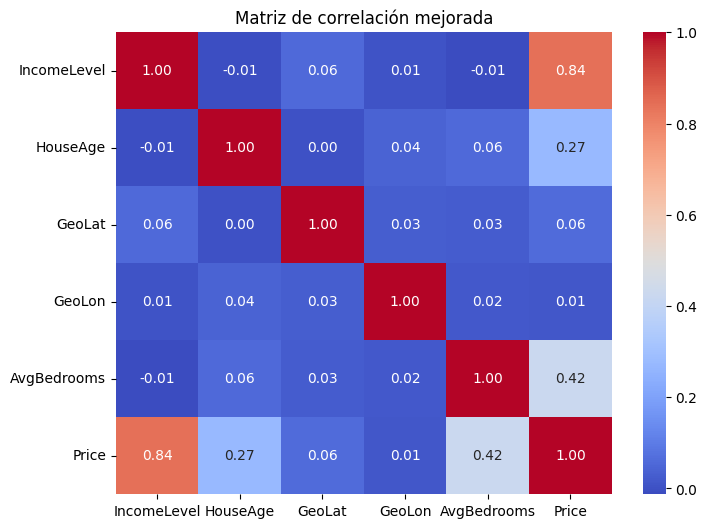

In [3]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(),annot=True,cmap='coolwarm',fmt='.2f')
plt.title('Matriz de correlación mejorada')
plt.show()

El precio de la vivienda muestra correlación fuerte con IncomeLevel y AvgBedrooms, lo que refuerza la idea de que el valor del inmueble depende del poder adquisitivo y tamaño promedio. La relación con HouseAge es moderada, mientras que las variables geográficas presentan correlaciones débiles, lo cual es esperado al ser una ciudad relativamente homogénea en este modelo sintético.

## 3. Modelo lineal multivariado

In [4]:
X=df[['IncomeLevel','HouseAge','GeoLat','GeoLon','AvgBedrooms']]
y=df['Price']
model=LinearRegression().fit(X,y)
y_pred=model.predict(X)
r2=r2_score(y,y_pred)
model.coef_, model.intercept_, r2

(array([15.01015004,  1.97355996,  1.21809133, -9.78185105, 81.23732858]),
 np.float64(-993.008671802035),
 0.9626202539545146)

## 4. Gráfica de residuos con interpretación

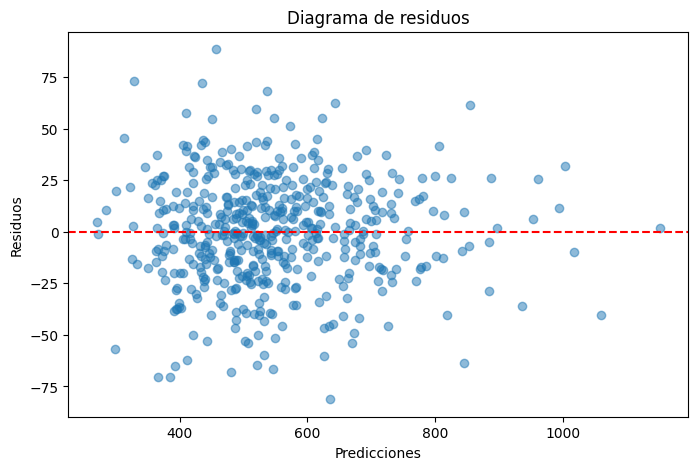

In [5]:
residuals=y - y_pred
plt.figure(figsize=(8,5))
plt.scatter(y_pred,residuals,alpha=0.5)
plt.axhline(0,color='red',linestyle='--')
plt.xlabel('Predicciones')
plt.ylabel('Residuos')
plt.title('Diagrama de residuos')
plt.show()

**Interpretación mejorada:**
Los residuos se distribuyen alrededor de cero sin mostrar patrones sistemáticos, lo cual indica que el modelo captura adecuadamente la tendencia general y no viola gravemente el supuesto de linealidad. La dispersión uniforme sugiere que no hay heterocedasticidad evidente.